# Structured variational autoencoders for count forecasting

Many time series are naturally described as partially observed dynamical systems. Neural spike trains are one example. A low-dimensional neural state evolves over time, while the observed spike counts of many neurons are generated from that state.

Let $n$ index sequences or experimental trials, $t$ index time, and $d$ index neurons. We consider a latent state $z_{n,t}\in\mathbb R^K$ with linear Gaussian dynamics,

$$
z_{n,0}\sim\mathcal N(m_0,S_0),
$$

$$
z_{n,t}\mid z_{n,t-1}
\sim
\mathcal N(Az_{n,t-1},Q),
$$

and conditionally independent Poisson observations,

$$
y_{n,t,d}\mid z_{n,t}
\sim
\operatorname{Poisson}
\left(
\Delta t\,\exp f_{\theta,d}(z_{n,t})
\right).
$$

Here $f_{\theta,d}$ is a nonlinear decoder giving the log firing rate of neuron $d$, and $\Delta t$ is the width of the time bin.

We want to do (potentially online) forecasting of future spikes. One approach is, from the observed start of a sequence, we infer the current latent state, propagate that state forward under the learned dynamics, and decode the resulting latent trajectory into future counts. 

The difficulty is learning the model. The latents are intractable to marginalise out from the joint model, so we will have to use some EM flavoured algorithm. However, the nonlinear Poisson emission is not conjugate to our linear gaussian prior. The latent posterior

$$
p(z_{n,0:T-1}\mid y_{n,0:T-1})
\propto
p(z_{n,0:T-1})
\prod_{t=0}^{T-1}
p(y_{n,t}\mid z_{n,t})
$$

is therefore not Gaussian, and an exact E-step is unavailable.

So, what posterior approximation to use instead? 

Learning the transition model requires pairwise marginal posterior moments. For example, the update $A^\star = \sum_t\mathbb E_q[z_tz_{t-1}^{\mathsf T}] \sum_t\mathbb E_q[z_{t-1}z_{t-1}^{\mathsf T}]^{-1}$ depends on

$$
\mathbb E_q[z_tz_{t-1}^{\mathsf T}],
$$

If we were to choose a temporally factorised (mean field) approximation,

$$
q(z_{0:T-1}\mid y)
=
\prod_{t=0}^{T-1}q(z_t\mid y).
$$

this would become $\mathbb E_q[z_t]\mathbb E_q[z_{t-1}]^{\mathsf T},
$ which is the claim that posterior cross covariance is 0. This is of course fair from reality, and thus dynamics learning will be poor. This motivates a structured variational posterior. One hope is that we retain the FO Markov structure of the implied exact posterior. Other critical characteristics are that computation of these expected statistics must be cheap, and we don't want to optimise a new posterior for each test experiment, so we should leverage amortisation.

### Structured VAEs


One solution here is a **structured variational autoencoder**. This preserves the graphical and functional structure of the latent model in the posterior. It does so by casting the nonconjugate emission factors into conjugate ones. A recognition network converts the observations into Gaussian potentials (here in natural form)

$$
\psi_{\phi}(z_{n,t};y_n)
\propto
\exp\left\{
-\frac12 z_{n,t}^{\mathsf T}
\Lambda_{n,t}
z_{n,t}
+
h_{n,t}^{\mathsf T}z_{n,t}
\right\},
$$

where $\Lambda_{n,t}\succeq 0$ and $h_{n,t}$ are outputs of the recognition network. These potentials are combined with the Gaussian dynamical prior:

$$
q_{\phi}(z_n\mid y_n)
\propto
p_{\Theta}(z_n)
\prod_{t=0}^{T-1}
\psi_{\phi}(z_{n,t};y_n).
$$

Strictly, the resulting posterior depends on both the recognition parameters and the current dynamical parameters, so we may write it as $q_{\phi,\Theta}(z_n\mid y_n)$. We suppress the dependence on $\Theta$ when it is clear from context.

We then freeze the posterior and do the typical updates on the parameters through the free energy: 
$$
\mathcal L
=
\sum_n
\mathbb E_{q_{\phi}(z_n\mid y_n)}
\left[
\log p_{\theta}(y_n\mid z_n)
\right]
-
\operatorname{KL}
\left(
q_{\phi}(z_n\mid y_n)
\,\Vert\,
p_{\Theta}(z_n)
\right).
$$



### Training


This gives an EM-like learning procedure.

In the **E-like step**, the recognition network produces the natural parameters of a Gaussian site $h_{n,t}$ and $\Lambda_{n,t}$ and we optimise a surrogate objective where the recognition sites replace the Poisson likelihood:

$\widetilde{\mathcal L}=\mathbb E_q[\log p_\Theta(z_n)+\sum_{t=0}^{T-1}\log\psi_\phi(z_{n,t};y_n)-\log q(z_n)]$.

The analytic optimal posterior is
$q_\phi(z_n\mid y_n)\propto p_\Theta(z_n)\prod_{t=0}^{T-1}\psi_\phi(z_{n,t};y_n)$.

Kalman filtering and smoothing in this posterior then give the moments required for learning the dynamics.

In the **M-like step**, these posterior moments are held fixed while the global model parameters are updated. The linear Gaussian parameters can be updated from expected sufficient statistics, while the nonlinear decoder is updated using gradients of the expected Poisson log likelihood. The recognition network is trained by differentiating the free energy through the Gaussian message-passing calculation.

Updates will be derived through the workbook 



##### Brief wrinkle to come back to 

As I am writing this, I realise that in theory we could use something like a deep state-space VAE. Can we not use the same linear Gaussian prior and constrain the posterior to be structured (block tridiagonal precision) gaussian, the parameters of which we have amortised directly? If we train this generalised EM style we should be able to do the same unrolling and decoding. We also do not lose the natural gradient SVI I will mention later, and we can still do dynamic programming for singleton and pairwise marginals. A huge theoretical upshot is that we will not have to use a surrogate objective, as we are instead doing constrained maximisation of the original free energy. This must be because it fails to learn dynamics practically ... but this is certainly soemthing to come back to. 


### Experiments

The experiments compare two versions of the structured VAE.

1. A **point-estimate structured VAE**, in which the recognition and decoder networks are trained by gradient methods and the linear dynamical parameters are treated as point estimates.

2. A **Bayesian structured VAE**, with a row-factorised Gaussian variational posterior over the transition matrix, and a diagonal Gaussian posterior over the first decoder layer. Columns of which share an ARD prior, which we optimise with a hyper M-step.

The Bayesian extension has two purposes. First, the ARD prior acts to regularise the model - hyper m steps cause precisions to diverge, in turn trimming latent directions that are weakly supported by both the dynamics and the decoder. Secondly, uncertainty over the transition and decoder parameters can be propagated into the forecast. This adds epistemic uncertainty to the process which already has some uncertainty from the posterior over latents.

In [1]:

%matplotlib inline

from dataclasses import replace
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

import importlib
import svae_forecasting as sf
importlib.reload(sf)

import svae_forecasting as sf

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

simulation_config = sf.SimulationConfig()
model_config = sf.ModelConfig(dt=simulation_config.dt)

simulation_config, model_config


(SimulationConfig(num_train=12, num_validation=2, num_test=3, time_steps=100, observed_steps=50, true_latent_dim=2, decoder_hidden_dim=12, num_observed_dims=10, dt=0.2, rotation_radius=0.975, rotation_angle=0.2, process_std=(0.075, 0.055), initial_std=(0.9, 0.7), mean_rate=6.0, seed=7),
 ModelConfig(latent_dim=20, recognition_hidden_dim=24, decoder_hidden_dim=16, dt=0.2, min_site_precision=0.0001, variance_floor=0.0001, initial_process_std=0.2, initial_site_precision=0.35, log_rate_clip=7.0, information_jitter=1e-05))

### Synthetic DGP

Our data-generating process is intentionally quite friendly. 

The true latent state is two-dimensional. Each sequence follows

$$
z_{n,0}\sim\mathcal N(0,S_0),
\qquad
S_0=\operatorname{diag}(0.9^2,0.7^2),
$$

and

$$
z_{n,t+1}
=
A_{\mathrm{true}}z_{n,t}
+
\epsilon_{n,t},
\qquad
\epsilon_{n,t}\sim\mathcal N(0,Q_{\mathrm{true}}),
$$

with

$$
A_{\mathrm{true}}
=
0.975
\begin{bmatrix}
\cos(0.20)&-\sin(0.20)\\
\sin(0.20)&\cos(0.20)
\end{bmatrix},
$$

and

$$
Q_{\mathrm{true}}
=
\operatorname{diag}(0.075^2,0.055^2).
$$

The transition is a damped rotation with eigenvalues $
0.975e^{\pm 0.20i}$ 

Hence, the latent state rotates while slowly contracting towards the origin. 

A one-hidden-layer nonlinear decoder maps the state to ten Poisson rates.

$$
\lambda_{n,t,d}
=
\Delta t\,\exp f_{\theta_{\mathrm{true}},d}(z_{n,t}),
$$

$$
y_{n,t,d}\sim\operatorname{Poisson}(\lambda_{n,t,d}).
$$

These ys are the neuron spike counts. 

There are twelve training sequences, two validation sequences, and three test sequences. Each full sequence has one hundred time bins. Only the first fifty bins of the training and validation sequences are passed to the fitting routines. For the test sequences, the first fifty bins are observed, and the remaining fifty bins are retained solely for forecast evaluation.

The first plot shows the true latent rotation, the induced rates, and the forecast boundary. The rates, rather than sampled counts, reveal the underlying signal which the model is trying to learn through Poisson noise.

training prefix: (12, 50, 10)
validation prefix: (2, 50, 10)
test full sequence: (3, 100, 10)
forecast horizon: 50


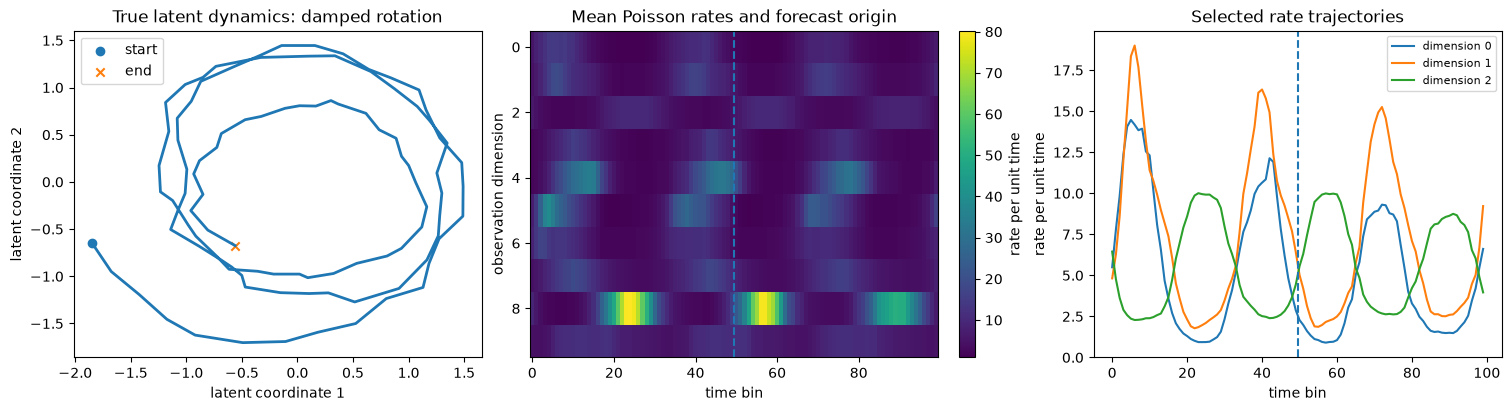

In [2]:

dataset = sf.simulate_dataset(simulation_config)
train_counts_full, train_rates_full, train_latents_full = dataset.arrays("train")
validation_counts_full, validation_rates_full, validation_latents_full = dataset.arrays("validation")
test_counts_full, test_rates_full, test_latents_full = dataset.arrays("test")

T_obs = simulation_config.observed_steps
H = simulation_config.forecast_horizon

# These are the only arrays passed to fitting functions.
train_counts = train_counts_full[:, :T_obs]
validation_counts = validation_counts_full[:, :T_obs]

assert train_counts.shape[1] == T_obs
assert validation_counts.shape[1] == T_obs
assert test_counts_full[:, T_obs:].shape[1] == H

print("training prefix:", train_counts.shape)
print("validation prefix:", validation_counts.shape)
print("test full sequence:", test_counts_full.shape)
print("forecast horizon:", H)

sf.plot_dgp_example(
    dataset,
    split="test",
    sequence_index=0,
    output_path=OUTPUT_DIR / "01_dgp_and_boundary.png",
)
plt.show()


# Point Estimate Structured VAE

For $n=1,\ldots,N$, $t=0,\ldots,T-1$, and $d=1,\ldots,D$, the probability model is

$$
\begin{aligned}
z_{n,0}
&\sim
\mathcal N(m_0,S_0),
&
m_0&\in\mathbb R^K,
&
S_0&\in\mathbb S_{++}^{K},
\\
z_{n,t}\mid z_{n,t-1}
&\sim
\mathcal N(Az_{n,t-1},Q),
&
A&\in\mathbb R^{K\times K},
&
Q&\in\mathbb S_{++}^{K},
\\
y_{n,t,d}\mid z_{n,t}
&\sim
\operatorname{Poisson}
\left(
\Delta t\,\exp f_{\gamma,d}(z_{n,t})
\right),
&
y_{n,t}&\in\mathbb N_0^D.
\end{aligned}
$$

For a one-hidden-layer decoder with $H$ hidden units,

$$
f_\gamma(z)
=
W_2\,\sigma(W_1z+b_1)+b_2,
$$

where

$$
W_1\in\mathbb R^{H\times K},
\qquad
b_1\in\mathbb R^H,
\qquad
W_2\in\mathbb R^{D\times H},
\qquad
b_2\in\mathbb R^D.
$$

Thus,

$$
p_{\Theta,\gamma}(y_n,z_n)
=
p_\Theta(z_{n,0})
\prod_{t=1}^{T-1}
p_\Theta(z_{n,t}\mid z_{n,t-1})
\prod_{t=0}^{T-1}
p_\gamma(y_{n,t}\mid z_{n,t}),
$$

with $\Theta=(m_0,S_0,A,Q)$.

The recognition network has outputs

$$
r_\phi:
\mathbb N_0^{T\times D}
\longrightarrow
\left(
\mathbb R^K\times\mathbb S_+^K
\right)^T,
$$

$$
r_\phi(y_n)
=
\left\{
h_{n,t},\Lambda_{n,t}
\right\}_{t=0}^{T-1},
$$

where

$$
h_{n,t}\in\mathbb R^K,
\qquad
\Lambda_{n,t}\in\mathbb S_+^K,
$$

and

$$
\psi_\phi(z_{n,t};y_n)
=
\exp
\left\{
-\frac12z_{n,t}^{\mathsf T}
\Lambda_{n,t}z_{n,t}
+
h_{n,t}^{\mathsf T}z_{n,t}
\right\}.
$$

We train this with generalised EM

## Generalised E-step

As we will see, the M-step depends on the full-data expectations

$$
\sum_{n=1}^N
\mathbb E_q[z_{n,0}],
\qquad
\sum_{n=1}^N
\mathbb E_q[z_{n,0}z_{n,0}^{\mathsf T}],
$$

$$
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_q[z_{n,t-1}z_{n,t-1}^{\mathsf T}],
\qquad
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_q[z_{n,t}z_{n,t-1}^{\mathsf T}],
$$

and

$$
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_q[z_{n,t}z_{n,t}^{\mathsf T}].
$$

Hence,

Consider the surrogate objective

$$
\widetilde{\mathcal L}_n(q)
=
\mathbb E_q
\left[
\log p_\Theta(z_n)
+
\sum_{t=0}^{T-1}
\log\psi_\phi(z_{n,t};y_n)
-
\log q(z_n)
\right].
$$

For each sequence $n$, the recognition model has outputted natural params

$$
\left\{
h_{n,t},\Lambda_{n,t}
\right\}_{t=0}^{T-1}.
$$

The analytic optimum of the surrogate objective is

$$
q_{\phi,\Theta}^{\star}(z_n\mid y_n)
\propto
p_\Theta(z_n)
\prod_{t=0}^{T-1}
\psi_\phi(z_{n,t};y_n),
$$

There are equivalent bookkeeping techniques to extract the quantities of interest: Either we have collected pseudo-observations in a linear-Gaussian system in which we do Kalman filtering and RTS smoothing for the posterior marginals, or we form a block tridiagonal gaussian and do information form gaussian smoothing.

Writing

$$
\mathbf z_n
=
\begin{bmatrix}
z_{n,0}\\
\vdots\\
z_{n,T-1}
\end{bmatrix},
$$

the posterior has information form

$$
q(z_n\mid y_n)
\propto
\exp
\left\{
-\frac12\mathbf z_n^{\mathsf T}
J_n\mathbf z_n
+
\xi_n^{\mathsf T}\mathbf z_n
\right\}.
$$

The diagonal blocks of $J_n$ are

$$
J_{n,0,0}
=
S_0^{-1}
+
\Lambda_{n,0}
+
A^{\mathsf T}Q^{-1}A,
$$

$$
J_{n,t,t}
=
Q^{-1}
+
\Lambda_{n,t}
+
A^{\mathsf T}Q^{-1}A,
\qquad
1\leq t\leq T-2,
$$

$$
J_{n,T-1,T-1}
=
Q^{-1}
+
\Lambda_{n,T-1},
$$

and its off-diagonal blocks are

$$
J_{n,t,t-1}
=
-Q^{-1}A,
\qquad
J_{n,t-1,t}
=
-A^{\mathsf T}Q^{-1},
\qquad
1\leq t\leq T-1.
$$

The information vectors are

$$
\xi_{n,0}
=
S_0^{-1}m_0+h_{n,0},
\qquad
\xi_{n,t}
=
h_{n,t},
\quad
1\leq t\leq T-1.
$$

The recursive updates from information form Gaussian smoothing are

$$
\widetilde J_{n,0}
=
J_{n,0,0},
\qquad
\widetilde \xi_{n,0}
=
\xi_{n,0},
$$

and, for $t=1,\ldots,T-1$,

$$
\widetilde J_{n,t}
=
J_{n,t,t}
-
J_{n,t,t-1}
\widetilde J_{n,t-1}^{-1}
J_{n,t-1,t},
$$

$$
\widetilde \xi_{n,t}
=
\xi_{n,t}
-
J_{n,t,t-1}
\widetilde J_{n,t-1}^{-1}
\widetilde \xi_{n,t-1}.
$$

Define

$$
P_{n,t}
=
\widetilde J_{n,t}^{-1},
\qquad
a_{n,t}
=
P_{n,t}\widetilde \xi_{n,t},
$$

and, for $t=0,\ldots,T-2$,

$$
G_{n,t}
=
-P_{n,t}J_{n,t,t+1}.
$$

The backward recursion is initialised by

$$
\mu_{n,T-1}
=
a_{n,T-1},
\qquad
\Sigma_{n,T-1}
=
P_{n,T-1},
$$

and then

$$
\mu_{n,t}
=
a_{n,t}
+
G_{n,t}\mu_{n,t+1},
$$

$$
\Sigma_{n,t}
=
P_{n,t}
+
G_{n,t}\Sigma_{n,t+1}G_{n,t}^{\mathsf T},
$$

$$
\Sigma_{n,t,t+1}
=
G_{n,t}\Sigma_{n,t+1},
\qquad
t=T-2,\ldots,0.
$$

and then we compute singleton and pairwise marginals

$$
q(z_{n,t}\mid y_n)
=
\mathcal N
\left(
z_{n,t};
\mu_{n,t},
\Sigma_{n,t}
\right),
$$

and

$$
q(z_{n,t-1},z_{n,t}\mid y_n)
=
\mathcal N
\left(
\begin{bmatrix}
z_{n,t-1}\\
z_{n,t}
\end{bmatrix};
\begin{bmatrix}
\mu_{n,t-1}\\
\mu_{n,t}
\end{bmatrix},
\begin{bmatrix}
\Sigma_{n,t-1}
&
G_{n,t-1}\Sigma_{n,t}
\\
\Sigma_{n,t}G_{n,t-1}^{\mathsf T}
&
\Sigma_{n,t}
\end{bmatrix}
\right).
$$

and sufficient statistics

$$
\mathbb E_q[z_{n,t}]
=
\mu_{n,t},
$$

$$
\mathbb E_q[z_{n,t}z_{n,t}^{\mathsf T}]
=
\Sigma_{n,t}
+
\mu_{n,t}\mu_{n,t}^{\mathsf T},
$$

$$
\mathbb E_q[z_{n,t}z_{n,t-1}^{\mathsf T}]
=
\Sigma_{n,t}G_{n,t-1}^{\mathsf T}
+
\mu_{n,t}\mu_{n,t-1}^{\mathsf T}.
$$

and finally we can thus form the full data quantities:

$$
\sum_{n=1}^N\mu_{n,0},
\qquad
\sum_{n=1}^N
\left(
\Sigma_{n,0}
+
\mu_{n,0}\mu_{n,0}^{\mathsf T}
\right),
$$

$$
\sum_{n=1}^N\sum_{t=1}^{T-1}
\left(
\Sigma_{n,t-1}
+
\mu_{n,t-1}\mu_{n,t-1}^{\mathsf T}
\right),
$$

$$
\sum_{n=1}^N\sum_{t=1}^{T-1}
\left(
\Sigma_{n,t}
+
\mu_{n,t}\mu_{n,t}^{\mathsf T}
\right),
$$

and

$$
\sum_{n=1}^N\sum_{t=1}^{T-1}
\left(
\Sigma_{n,t}G_{n,t-1}^{\mathsf T}
+
\mu_{n,t}\mu_{n,t-1}^{\mathsf T}
\right).
$$

## Generalised M-step

We now switch from the surrogate objective to the free energy. We optimise this with respect to the parameters of the dynamics, decoder, and recognition network. The dynamics are updated analytically. The decoder and recognition parameters are updated by following gradients.

### Dynamics Parameters

Updates for $A$, $Q$, $m_0$, $Q_0$, are available analytically when we have the expected sufficient statistics. Differentiating with respect to each, and setting this to zero (as done in the literature countless times), we obtain updates:

$$
A^\star
=
\left(
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_q
\left[
 z_{n,t}z_{n,t-1}^{\mathsf T}
\right]
\right)
\left(
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_q
\left[
 z_{n,t-1}z_{n,t-1}^{\mathsf T}
\right]
\right)^{-1},
$$

$$
Q^\star
=
\frac{1}{M}
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_q
\left[
\left(z_{n,t}-A^\star z_{n,t-1}\right)
\left(z_{n,t}-A^\star z_{n,t-1}\right)^{\mathsf T}
\right],
$$

$$
m_0^\star
=
\frac{1}{N}
\sum_{n=1}^N
\mathbb E_q[z_{n,0}],
$$

$$
S_0^\star
=
\frac{1}{N}
\sum_{n=1}^N
\mathbb E_q
\left[
(z_{n,0}-m_0^\star)
(z_{n,0}-m_0^\star)^{\mathsf T}
\right].
$$

### Decoder Parameters

The objective for the decoder with parameters $\gamma$ is

$$
\begin{aligned}
\mathcal L_\gamma
&=
\sum_{n=1}^N
\sum_{t=0}^{T-1}
\sum_{d=1}^D
\mathbb E_q
\Big[
y_{n,t,d}
\big(
\log\Delta t
+
f_{\gamma,d}(z_{n,t})
\big)
\\
&\hspace{7em}
-
\Delta t\,\exp f_{\gamma,d}(z_{n,t})
-
\log\Gamma(y_{n,t,d}+1)
\Big].
\end{aligned}
$$

This likelihood term is nonlinear, so we estimate it by drawing monte carlo samples from the latent posterior, treating them as fixed and pushing them through the likelihood term, to obtain an unbiased estimator (which here we also compute by minibatching):

$$
z_n^{(s)}
\sim
q_{\phi,\Theta}(z_n\mid y_n),
\qquad
s=1,\ldots,S,
$$

$$
\begin{aligned}
\widehat{\mathcal L}_\gamma
&=
\frac{N}{|\mathcal B|S}
\sum_{n\in\mathcal B}
\sum_{s=1}^S
\sum_{t=0}^{T-1}
\sum_{d=1}^D
\Big[
y_{n,t,d}
\big(
\log\Delta t
+
f_{\gamma,d}(z_{n,t}^{(s)})
\big)
\\
&\hspace{7em}
-
\Delta t\,\exp f_{\gamma,d}(z_{n,t}^{(s)})
-
\log\Gamma(y_{n,t,d}+1)
\Big].
\end{aligned}
$$

Then we take an optimiser step in these parameters.

$$
\gamma^{(r+1)}
=
\operatorname{OptStep}
\left(
\gamma^{(r)},
\widehat{\nabla_\gamma {\mathcal L}_\gamma}
\right).
$$


### Recognition Network Parameters

Unlike the decoder and dynamics updates, we cannot treat the posterior over latents as fixed, as the recognition network only affects the free energy through changing the latent posterior. Fortunately, the information smoother is a differentiable computation, and Jax is really fantastic at fast autodiff through this sort of procedure.

$$
y_n
\xrightarrow{\ r_\phi\ }
\{h_{n,t},\Lambda_{n,t}\}_{t=0}^{T-1}
\xrightarrow{\ \text{assemble}\ }
(J_n,\xi_n)
\xrightarrow{\ \text{information smoother}\ }
\{\mu_{n,t},\Sigma_{n,t},\Sigma_{n,t,t-1}\}_{t=0}^{T-1}
$$

$$
\xrightarrow{\ \text{differentiable Gaussian sampling}\ }
z_n^{(s)}
\xrightarrow{\ \text{free energy}\ }
\widehat{\mathcal L}.
$$

Thus,

$$
\widehat{\nabla_\phi\mathcal L}
=
\frac{\partial\widehat{\mathcal L}}{\partial z}
\frac{\partial z}{\partial(\mu,\Sigma)}
\frac{\partial(\mu,\Sigma)}
{\partial(J,\xi)}
\frac{\partial(J,\xi)}
{\partial(h,\Lambda)}
\frac{\partial(h,\Lambda)}
{\partial\phi}.
$$

We then take an optimiser step in these parameters.

$$
\phi^{(r+1)}
=
\operatorname{OptStep}
\left(
\phi^{(r)},
\widehat{\nabla_\phi\mathcal L}
\right).
$$



### Training logistics

The point-estimate model uses 3,000 steps, a full batch of 12 sequences, and four Monte Carlo samples. During training, the final 15 observations of the 50-bin training prefix are masked from the recognition network, although their counts still contribute to the free energy.

Adam with learning rate $2 \times 10^{-3}$ updates the recognition network and decoder parameters. In the same iteration, closed-form generalised-EM targets are computed for the transition matrix $A$, process noise $Q$, initial mean $m_0$, and initial covariance $S_0$. These parameters updates are damped by a factor of $0.08$

We use a random initialisation of these parameters. 

The point-model free energy contains only the local latent-variable terms and does not include global parameter KL penalties.

In [3]:
initial_key = jax.random.PRNGKey(11)
initial_point_params = sf.initialise_point_model(
    initial_key,
    train_counts,
    model_config,
)

point_config = sf.PointTrainingConfig(
    num_steps=3000,
    batch_size=12,
    learning_rate=2e-3,
    dynamics_step_size=0.08,
    mask_horizon=15,
    num_mc_samples=4,
    log_every=10,
    seed=10,
)

point_params, point_history = sf.fit_point_model(
    train_counts,
    validation_counts,
    model_config,
    point_config,
    initial_params=initial_point_params,
    verbose=True,
)


point step 0000 | free energy -859.08 | val -856.56 | rho(A) 0.896
point step 0010 | free energy -858.35 | val -855.42 | rho(A) 0.866
point step 0020 | free energy -857.24 | val -855.58 | rho(A) 0.844
point step 0030 | free energy -855.72 | val -852.02 | rho(A) 0.828
point step 0040 | free energy -852.77 | val -844.07 | rho(A) 0.818
point step 0050 | free energy -834.37 | val -833.14 | rho(A) 0.826
point step 0060 | free energy -806.79 | val -796.13 | rho(A) 0.861
point step 0070 | free energy -804.89 | val -796.26 | rho(A) 0.908
point step 0080 | free energy -765.56 | val -773.61 | rho(A) 0.937
point step 0090 | free energy -757.74 | val -752.86 | rho(A) 0.955
point step 0100 | free energy -742.64 | val -752.85 | rho(A) 0.968
point step 0110 | free energy -735.78 | val -739.98 | rho(A) 0.976
point step 0120 | free energy -731.94 | val -741.90 | rho(A) 0.981
point step 0130 | free energy -729.69 | val -728.48 | rho(A) 0.984
point step 0140 | free energy -726.21 | val -739.89 | rho(A) 0

# Bayesian structured VAE with ARD

The model is

$$
z_{n,0}
\sim
\mathcal N(m_0,S_0),
$$

$$
z_{n,t}\mid z_{n,t-1},A
\sim
\mathcal N(Az_{n,t-1},Q),
\qquad
Q
=
\operatorname{diag}(\nu_1,\ldots,\nu_K),
$$

$$
y_{n,t,d}\mid z_{n,t},W_1,\rho
\sim
\operatorname{Poisson}
\left(
\Delta t\,\exp f_{W_1,\rho,d}(z_{n,t})
\right),
$$

where

$$
f_{W_1,\rho}(z)
=
W_2\sigma(W_1z+b_1)+b_2,
\qquad
\rho=(b_1,W_2,b_2).
$$

Writing

$$
a_i
=
A_{i:}^{\mathsf T}
\in\mathbb R^K,
$$

the candidate posterior over the transition matrix is

$$
q(A)
=
\prod_{i=1}^K
\mathcal N
\left(
a_i;
\mu_i^A,V_i^A
\right),
$$

and the candidate posterior over the first decoder layer is

$$
q(W_1)
=
\prod_{j=1}^H
\prod_{k=1}^K
\mathcal N
\left(
W_{1,jk};
\mu_{jk}^W,
(\sigma_{jk}^W)^2
\right).
$$

where we put a shared ARD prior on both the columns of the dynamics $A$, and the first layer weights $W$ of the decoder. This is because, for a dimension to be redundant, it has to be redundant both for dynamics and for prediction.

$$
\begin{aligned}
p(A\mid\alpha)
&=
\prod_{k=1}^K
\mathcal N
\left(
A_{:k};
0,\alpha_k^{-1}I_K
\right)
\\
&=
\prod_{i=1}^K
\mathcal N
\left(
a_i;
0,D_\alpha^{-1}
\right),
\end{aligned}
$$

$$
p(W_1\mid\alpha)
=
\prod_{k=1}^K
\mathcal N
\left(
W_{1,:k};
0,\alpha_k^{-1}I_H
\right),
$$

where

$$
D_\alpha
=
\operatorname{diag}(\alpha_1,\ldots,\alpha_K),
$$




## Generalised E-Step

Again, the latent update supplies the full-data expectations

$$
\sum_{n=1}^N
\mathbb E_{q_n}[z_{n,0}],
\qquad
\sum_{n=1}^N
\mathbb E_{q_n}[z_{n,0}z_{n,0}^{\mathsf T}],
$$

$$
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_{q_n}[z_{n,t-1}z_{n,t-1}^{\mathsf T}],
\qquad
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_{q_n}[z_{n,t}z_{n,t-1}^{\mathsf T}],
$$

and

$$
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_{q_n}[z_{n,t}z_{n,t}^{\mathsf T}].
$$

The surrogate objective is

$$
\widetilde{\mathcal L}_n(q_n)
=
\mathbb E_{q_n(z_n)q(A)}
\left[
\log p_\Theta(z_n\mid A)
+
\sum_{t=0}^{T-1}
\log\psi_\phi(z_{n,t};y_n)
-
\log q_n(z_n)
\right].
$$

The analytic optimum is

$$
q_n^\star(z_n)
\propto
\exp
\left\{
\mathbb E_{q(A)}
\left[
\log p_\Theta(z_n\mid A)
\right]
+
\sum_{t=0}^{T-1}
\log\psi_\phi(z_{n,t};y_n)
\right\}.
$$

Which is the same except we are now taking an expectaiton over $A$. 

The required expectations are

$$
\mathbb E_{q(A)}[A]_{i:}
=
(\mu_i^A)^{\mathsf T},
$$

and

$$
\begin{aligned}
\mathbb E_{q(A)}
\left[
A^{\mathsf T}Q^{-1}A
\right]
&=
\mathbb E_{q(A)}[A]^{\mathsf T}
Q^{-1}
\mathbb E_{q(A)}[A]
+
\sum_{i=1}^K
\nu_i^{-1}V_i^A.
\end{aligned}
$$

We can basically do the same computations again as above. The diagonal information blocks become

$$
J_{n,0,0}
=
S_0^{-1}
+
\Lambda_{n,0}
+
\mathbb E_{q(A)}
\left[
A^{\mathsf T}Q^{-1}A
\right],
$$

$$
J_{n,t,t}
=
Q^{-1}
+
\Lambda_{n,t}
+
\mathbb E_{q(A)}
\left[
A^{\mathsf T}Q^{-1}A
\right],
\qquad
1\leq t\leq T-2,
$$

$$
J_{n,T-1,T-1}
=
Q^{-1}
+
\Lambda_{n,T-1},
$$

while the off-diagonal blocks become

$$
J_{n,t,t-1}
=
-Q^{-1}\mathbb E_{q(A)}[A],
\qquad
J_{n,t-1,t}
=
-\mathbb E_{q(A)}[A]^{\mathsf T}Q^{-1}.
$$

The information vectors remain

$$
\xi_{n,0}
=
S_0^{-1}m_0+h_{n,0},
\qquad
\xi_{n,t}
=
h_{n,t}.
$$

The same recursions then give

$$
q_n^\star(z_{n,t})
=
\mathcal N
\left(
z_{n,t};
\mu_{n,t},
\Sigma_{n,t}
\right),
$$

$$
q_n^\star(z_{n,t-1},z_{n,t})
=
\mathcal N
\left(
\begin{bmatrix}
z_{n,t-1}\\
z_{n,t}
\end{bmatrix};
\begin{bmatrix}
\mu_{n,t-1}\\
\mu_{n,t}
\end{bmatrix},
\begin{bmatrix}
\Sigma_{n,t-1}
&
G_{n,t-1}\Sigma_{n,t}
\\
\Sigma_{n,t}G_{n,t-1}^{\mathsf T}
&
\Sigma_{n,t}
\end{bmatrix}
\right),
$$

which we use to form the above sufficient statistics.

## Generalised (Variational) M-Step

We are now being bayesian about the dynamics and decoder parameters. We thus want candidate posterior distributions $q$ over $A$ and $W$. We optimise these with respect to the free energy

$$
\begin{aligned}
\mathcal L
={}&
\sum_{n=1}^N
\mathbb E_{q_n(z_n)q(W_1)}
\left[
\log p(y_n\mid z_n,W_1,\rho)
\right]
\\
&+
\sum_{n=1}^N
\mathbb E_{q_n(z_n)q(A)}
\left[
\log p_\Theta(z_n\mid A)
\right]
+
\sum_{n=1}^N
\mathcal H[q_n]
\\
&-
\operatorname{KL}
\left(
q(A)\,\Vert\,p(A\mid\alpha)
\right)
-
\operatorname{KL}
\left(
q(W_1)\,\Vert\,p(W_1\mid\alpha)
\right).
\end{aligned}
$$

### A Dynamics

Although the column wise prior view on $A$ is helpful to understand ARD, it is convenient to represent the candidate posterior row-wise. This is because future updates contain

$$
\begin{aligned}
\mathbb E_{q(A)}
\left[
A^{\mathsf T}Q^{-1}A
\right]
&=
\sum_{i=1}^K
\nu_i^{-1}
\mathbb E_{q(a_i)}
\left[
a_i a_i^{\mathsf T}
\right]
\\
&=
\sum_{i=1}^K
\nu_i^{-1}
\left(
V_i^A
+
\mu_i^A(\mu_i^A)^{\mathsf T}
\right),
\end{aligned}
$$

which we have described as a precision weighted sum of outer products of the rows $a_i$

Noting that we impose a normal prior, the linear normal dynamics means that $A$ has conjugate posterior updates given the sufficient statistcs. Again, a standard computation in the literature, the optimal posterior is multivariate normal that factors row-wise:

$$
q^\star(A)
=
\prod_{i=1}^K
\mathcal N
\left(
a_i;
\mu_i^{A,\star},
V_i^{A,\star}
\right).
$$

The coordinate-optimal covariance and mean for row $i$ are

$$
V_i^{A,\star}
=
\left(
D_\alpha
+
\nu_i^{-1}
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_{q_n}
\left[
z_{n,t-1}z_{n,t-1}^{\mathsf T}
\right]
\right)^{-1},
$$

$$
\mu_i^{A,\star}
=
V_i^{A,\star}
\nu_i^{-1}
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_{q_n}
\left[
z_{n,t-1}z_{n,t,i}
\right].
$$

We might be wary of this updating scheme. We are only using a minibatch of the experiments when computing the posterior over latents, so the computed update for $q(A)$ is an estimate. This might be quite noisy. For a minibatch $\mathcal B$, we therefore use the corresponding full-data-scaled sums directly in the natural-parameter update below.

Instead of jumping directly to the analytic optimum of the estimated objective, we do something called a natural gradient update.

It would be helpful to read the following blog post. [MLG Cambridge blog post](https://mlg.eng.cam.ac.uk/blog/2021/04/13/ngvi-bnns-part-1.html)

I will give a brief explanation here.

We first choose a variational family, here a row-factored gaussian posterior over $A$, which is in the same family as the column-wise prior which we can see if we represent in row wise form

$$
\begin{aligned}
p(A\mid\alpha)
&=
\prod_{k=1}^K
\mathcal N
\left(
A_{:k};
0,\alpha_k^{-1}I_K
\right)
\\
&=
\prod_{i=1}^K
\mathcal N
\left(
a_i;
0,D_\alpha^{-1}
\right).
\end{aligned}
$$

For one row,

$$
q_{\eta_i}(a_i)
=
\exp
\left\{
(\eta_{i,1})^{\mathsf T}a_i
+
a_i^{\mathsf T}\eta_{i,2}a_i
-
\mathcal A(\eta_i)
\right\},
$$

with natural parameters

$$
\eta_{i,1}
=
(V_i^A)^{-1}\mu_i^A,
\qquad
\eta_{i,2}
=
-\frac12(V_i^A)^{-1},
$$

and expectation parameters

$$
m_{i,1}
=
\mathbb E[a_i]
=
\mu_i^A,
\qquad
m_{i,2}
=
\mathbb E[a_i a_i^{\mathsf T}]
=
V_i^A+\mu_i^A(\mu_i^A)^{\mathsf T}.
$$

Now, for a general family of distributions, a natural gradient step is an update of the form

$$
\eta^{(r+1)}
=
\eta^{(r)}
+
\rho_r
F(\eta^{(r)})^{-1}
\nabla_\eta
\mathcal L(\eta^{(r)}),
$$

where

$$
F(\eta)
=
\mathbb E_{q_\eta}
\left[
\nabla_\eta\log q_\eta(a)
\nabla_\eta\log q_\eta(a)^{\mathsf T}
\right]
$$

is the fisher matrix. This preconditioning respects the information geometry of the space of distributions we are optimising over, and I would encourage reading the linked introduction for background. [Robotics Oxford](https://www.robots.ox.ac.uk/~lsgs/posts/2019-09-27-info-geom.html)

More practically, we now have an exponential family posterior, and exploiting the parameter duality of minimal exponential families, this update is just a normal gradient step in the expectation parameters. Hence our update becomes

$$
\eta^{(r+1)}
=
\eta^{(r)}
+
\rho_r
\nabla_m\mathcal L.
$$

For the conjugate update,

$$
\nabla_m\mathcal L
=
\widehat\eta^\star-\eta^{(r)},
$$

so

$$
\eta^{(r+1)}
=
(1-\rho_r)\eta^{(r)}
+
\rho_r\widehat\eta^\star.
$$

It turns out that this implies the following natural parameter update (where we have minibatched)

$$
\widehat\eta_{i,1}^\star
=
\nu_i^{-1}
\frac{N}{|\mathcal B|}
\sum_{n\in\mathcal B}
\sum_{t=1}^{T-1}
\mathbb E_{q_n}
\left[
z_{n,t-1}z_{n,t,i}
\right],
$$

$$
\widehat\eta_{i,2}^\star
=
-\frac12
\left(
D_\alpha
+
\nu_i^{-1}
\frac{N}{|\mathcal B|}
\sum_{n\in\mathcal B}
\sum_{t=1}^{T-1}
\mathbb E_{q_n}
\left[
z_{n,t-1}z_{n,t-1}^{\mathsf T}
\right]
\right),
$$

$$
\eta_{i,1}^{(r+1)}
=
(1-\rho_r)\eta_{i,1}^{(r)}
+
\rho_r\nu_i^{-1}
\frac{N}{|\mathcal B|}
\sum_{n\in\mathcal B}
\sum_{t=1}^{T-1}
\mathbb E_{q_n}
\left[
z_{n,t-1}z_{n,t,i}
\right],
$$

$$
\eta_{i,2}^{(r+1)}
=
(1-\rho_r)\eta_{i,2}^{(r)}
-
\frac{\rho_r}{2}
\left(
D_\alpha
+
\nu_i^{-1}
\frac{N}{|\mathcal B|}
\sum_{n\in\mathcal B}
\sum_{t=1}^{T-1}
\mathbb E_{q_n}
\left[
z_{n,t-1}z_{n,t-1}^{\mathsf T}
\right]
\right).
$$

The moments are recovered using

$$
V_i^{A,(r+1)}
=
\left(
-2\eta_{i,2}^{(r+1)}
\right)^{-1},
$$

$$
\mu_i^{A,(r+1)}
=
V_i^{A,(r+1)}
\eta_{i,1}^{(r+1)},
$$

Notice that this looks like a damped update. Unsurprisingly, this turns out to be more stable when we are computing relevant quantities stochastically, but also substantially faster to converge


### Other Dynamics Parameters

These remain similar to the point estimates above. Again, they are standard but incorporate the variational posterior over $A$:

$$
m_0^\star
=
\frac{1}{N}
\sum_{n=1}^N
\mathbb E_{q_n}[z_{n,0}],
$$

$$
S_0^\star
=
\frac{1}{N}
\sum_{n=1}^N
\mathbb E_{q_n}
\left[
(z_{n,0}-m_0^\star)
(z_{n,0}-m_0^\star)^{\mathsf T}
\right].
$$

For $Q=\operatorname{diag}(\nu_1,\ldots,\nu_K)$,

$$
\begin{aligned}
\nu_i^\star
=\frac{1}{M}
\Bigg[{}
&\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_{q_n}[z_{n,t,i}^2]
\\
&-
2(\mu_i^A)^{\mathsf T}
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_{q_n}
\left[
z_{n,t-1}z_{n,t,i}
\right]
\\
&+
\operatorname{tr}
\left\{
\left(
V_i^A
+
\mu_i^A(\mu_i^A)^{\mathsf T}
\right)
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_{q_n}
\left[
z_{n,t-1}z_{n,t-1}^{\mathsf T}
\right]
\right\}
\Bigg].
\end{aligned}
$$

Equivalently,

$$
Q^\star
=
\frac{1}{M}
\operatorname{diag}
\left(
\sum_{n=1}^N
\sum_{t=1}^{T-1}
\mathbb E_{q_n(z_n)q(A)}
\left[
\left(z_{n,t}-Az_{n,t-1}\right)
\left(z_{n,t}-Az_{n,t-1}\right)^{\mathsf T}
\right]
\right).
$$

### Decoder $W_1$

Here we employ a similar technique to make our decoder Bayesian. Choosing a fully factored Gaussian approximate posterior family for $W_1$, we compute natural gradients. Swaroop's [MLG Cambridge blog post](https://mlg.eng.cam.ac.uk/blog/2021/04/13/ngvi-bnns-part-1.html) gives the exact updates as we have a zero-mean Gaussian prior via ARD. We implement VOGN as described, minus the diagonal approximation. 

### Decoder other parameters

The objective is

$$
\mathcal L_\rho
=
\sum_{n=1}^N
\mathbb E_{q(W_1)q_n(z_n)}
\left[
\log p_\rho(y_n\mid z_n,W_1)
\right],
$$

which we approximate by Monte Carlo:

$$
W_1^{(s)}
\sim
q(W_1),
\qquad
z_n^{(s)}
\sim
q_n(z_n),
$$

$$
\widehat{\mathcal L}_\rho
=
\frac{N}{|\mathcal B|S}
\sum_{n\in\mathcal B}
\sum_{s=1}^S
\log p_\rho
\left(
y_n
\mid
z_n^{(s)},W_1^{(s)}
\right).
$$

We then use some generic optimiser step on these

$$
\rho^{(r+1)}
=
\operatorname{OptStep}
\left(
\rho^{(r)},
\nabla_\rho\widehat{\mathcal L}_\rho
\right).
$$

### Recognition Network

We again take a generic optimiser step, autodiffing through the latent smoothing procedure.

$$
y_n
\xrightarrow{\ r_\phi\ }
\{h_{n,t},\Lambda_{n,t}\}_{t=0}^{T-1}
\xrightarrow{\ \text{assemble}\ }
(J_n,\xi_n)
\xrightarrow{\ \text{information smoother}\ }
\{\mu_{n,t},\Sigma_{n,t},\Sigma_{n,t,t-1}\}_{t=0}^{T-1}
$$

$$
\xrightarrow{\ \text{differentiable Gaussian sampling}\ }
z_n^{(s)}
\xrightarrow{\ q(A),\,q(W_1),\,p(y,z,A,W_1)\ }
\widehat{\mathcal L}.
$$

Thus,

$$
\widehat{\nabla_\phi\mathcal L}
=
\frac{\partial\widehat{\mathcal L}}{\partial z}
\frac{\partial z}{\partial(\mu,\Sigma)}
\frac{\partial(\mu,\Sigma)}
{\partial(J,\xi)}
\frac{\partial(J,\xi)}
{\partial(h,\Lambda)}
\frac{\partial(h,\Lambda)}
{\partial\phi},
$$

and

$$
\phi^{(r+1)}
=
\operatorname{OptStep}
\left(
\phi^{(r)},
\widehat{\nabla_\phi\mathcal L}
\right).
$$

### ARD Hyper M-step

Perhaps unsurprisingly, we get a faily nice analytic update for each hyperparameter $\alpha$

$$
\alpha_k^\star
=
\frac{K+H}{
\displaystyle
\sum_{i=1}^K
\mathbb E_q[A_{ik}^2]
+
\sum_{j=1}^H
\mathbb E_q[W_{1,jk}^2]
},
$$

where

$$
\mathbb E_q[A_{ik}^2]
=
(\mu_{i,k}^A)^2
+
(V_i^A)_{kk},
$$

and

$$
\mathbb E_q[W_{1,jk}^2]
=
(\mu_{jk}^W)^2
+
(\sigma_{jk}^W)^2.
$$


### Training logistics

The Bayesian model uses 3,000 steps, a full batch of 12 sequences, four Monte Carlo samples, and we also train masking the last 15 observations.

Adam with learning rate $1.5\times10^{-3}$ updates the recognition network and deterministic decoder parameters. In the same iteration, $q(A)$ receives a damped conjugate natural-parameter update with step size $0.04$, the noise parameters use a damped moment update of $0.04$, and $q(W_1)$ receives a diagonal VOGN update with step size $0.025$.

ARD updates begin after 25 steps and are applied every 5 steps.

We initialise the point parameters from the same starting point as the other model, and for the Gaussian posteriors over the random parameters we choose the initial mean to be the same as the initial point parameter.

Because the Bayesian free energy also contains global parameter KL terms, its value should not be compared too literally with the point-model objective.

In [4]:

bayesian_config = sf.BayesianTrainingConfig(
    num_steps=3000,
    batch_size=12,
    learning_rate=1.5e-3,
    mask_horizon=15,
    num_mc_samples=4,
    q_a_step_size=0.04,
    noise_step_size=0.04,
    vogn_step_size=0.025,
    ard_step_size=0.05,
    ard_warmup_steps=25,
    ard_update_every=5,
    log_every=10,
    seed=10,
)

bayesian_initial = sf.initialise_bayesian_from_point(
    initial_point_params,
    bayesian_config,
)

bayesian_params, bayesian_history = sf.fit_bayesian_model(
    train_counts,
    validation_counts,
    model_config,
    bayesian_config,
    initial_params=bayesian_initial,
    verbose=True,
)


bayes step 0000 | free energy -1028.13 | val -1023.64 | rho(E[A]) 0.890 | alpha [1.00, 1.00]
bayes step 0010 | free energy -1017.83 | val -1014.35 | rho(E[A]) 0.826 | alpha [1.00, 1.00]
bayes step 0020 | free energy -1010.77 | val -1008.22 | rho(E[A]) 0.788 | alpha [1.00, 1.00]
bayes step 0030 | free energy -1000.34 | val -992.54 | rho(E[A]) 0.762 | alpha [1.32, 1.41]
bayes step 0040 | free energy -987.63 | val -980.02 | rho(E[A]) 0.741 | alpha [1.68, 1.91]
bayes step 0050 | free energy -976.01 | val -969.62 | rho(E[A]) 0.723 | alpha [2.09, 2.46]
bayes step 0060 | free energy -966.56 | val -961.77 | rho(E[A]) 0.706 | alpha [2.52, 3.05]
bayes step 0070 | free energy -958.96 | val -955.26 | rho(E[A]) 0.691 | alpha [2.96, 3.66]
bayes step 0080 | free energy -953.11 | val -950.62 | rho(E[A]) 0.676 | alpha [3.41, 4.26]
bayes step 0090 | free energy -949.34 | val -945.53 | rho(E[A]) 0.662 | alpha [3.85, 4.84]
bayes step 0100 | free energy -944.78 | val -943.15 | rho(E[A]) 0.650 | alpha [4.28

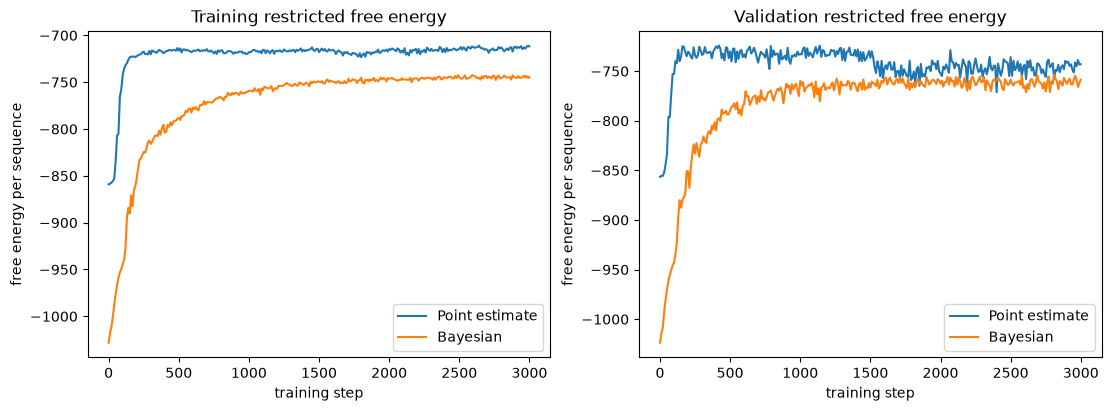

In [5]:
sf.plot_training_histories(
    {
        "Point estimate": point_history,
        "Bayesian": bayesian_history,
    },
    output_path=OUTPUT_DIR / "02_training_history.png",
)
plt.show()



# Forecasting Protocol 

For a test sequence, only $y_{0:T_{\mathrm{obs}}-1}$ is passed to recognition and smoothing. Let the terminal posterior be

$$
q(z_{T_{\mathrm{obs}}-1}\mid y_{0:T_{\mathrm{obs}}-1}).
$$

For the point model, each Monte Carlo trajectory samples the terminal state and then recursively draws

$$
z_{t+1}^{(s)}\sim\mathcal N(Az_t^{(s)},Q).
$$

For the Bayesian model, each trajectory first draws one

$$
A^{(s)}\sim q(A),\qquad W^{(1,s)}\sim q(W^{(1)}),
$$

and holds those global draws fixed over the entire horizon before drawing process and Poisson observation noise. This preserves coherent epistemic uncertainty across time.

We do this multiple times to compute the observed uncertainty.

In [6]:

test_prefix = test_counts_full[:, :T_obs]
test_suffix = test_counts_full[:, T_obs:]

point_forecast = sf.forecast_point_model(
    jax.random.PRNGKey(1001),
    point_params,
    test_prefix,
    H,
    num_samples=300,
    config=model_config,
)

bayesian_forecast = sf.forecast_bayesian_model(
    jax.random.PRNGKey(1002),
    bayesian_params,
    test_prefix,
    H,
    num_samples=300,
    config=model_config,
)

point_metrics = sf.probabilistic_forecast_metrics(
    point_forecast, test_suffix, model_config.dt
)
bayesian_metrics = sf.probabilistic_forecast_metrics(
    bayesian_forecast, test_suffix, model_config.dt
)


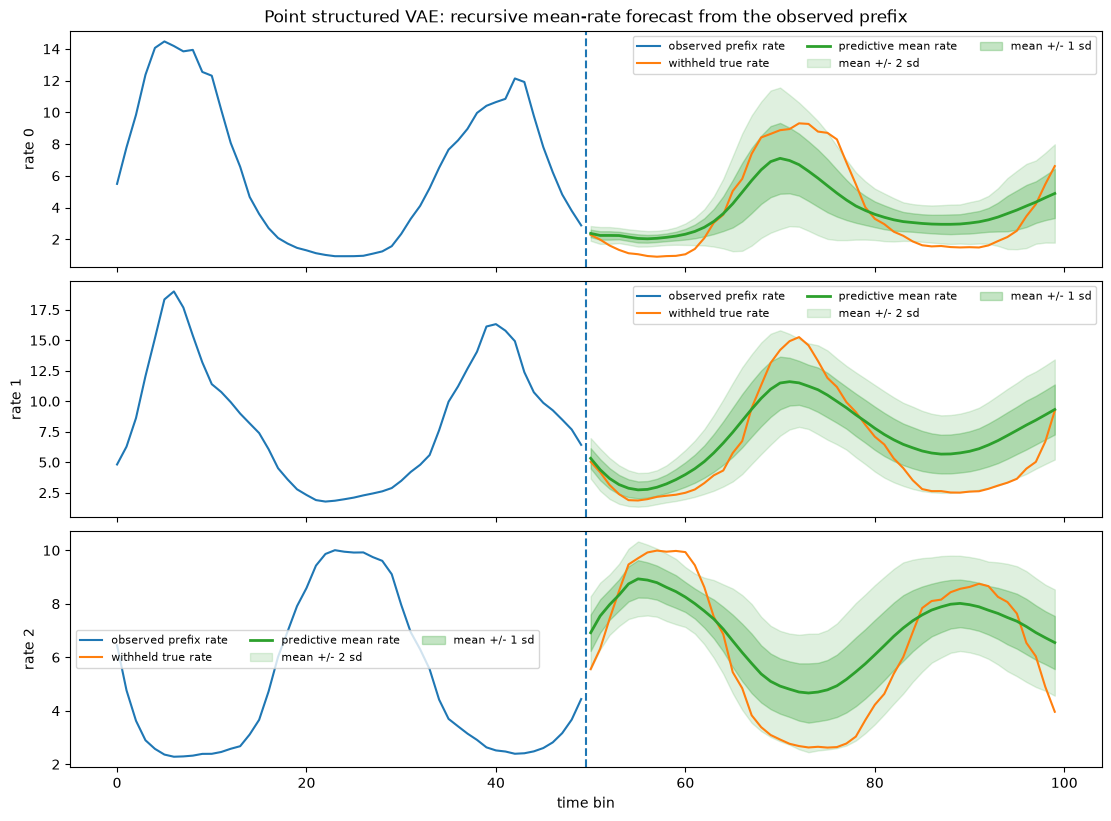

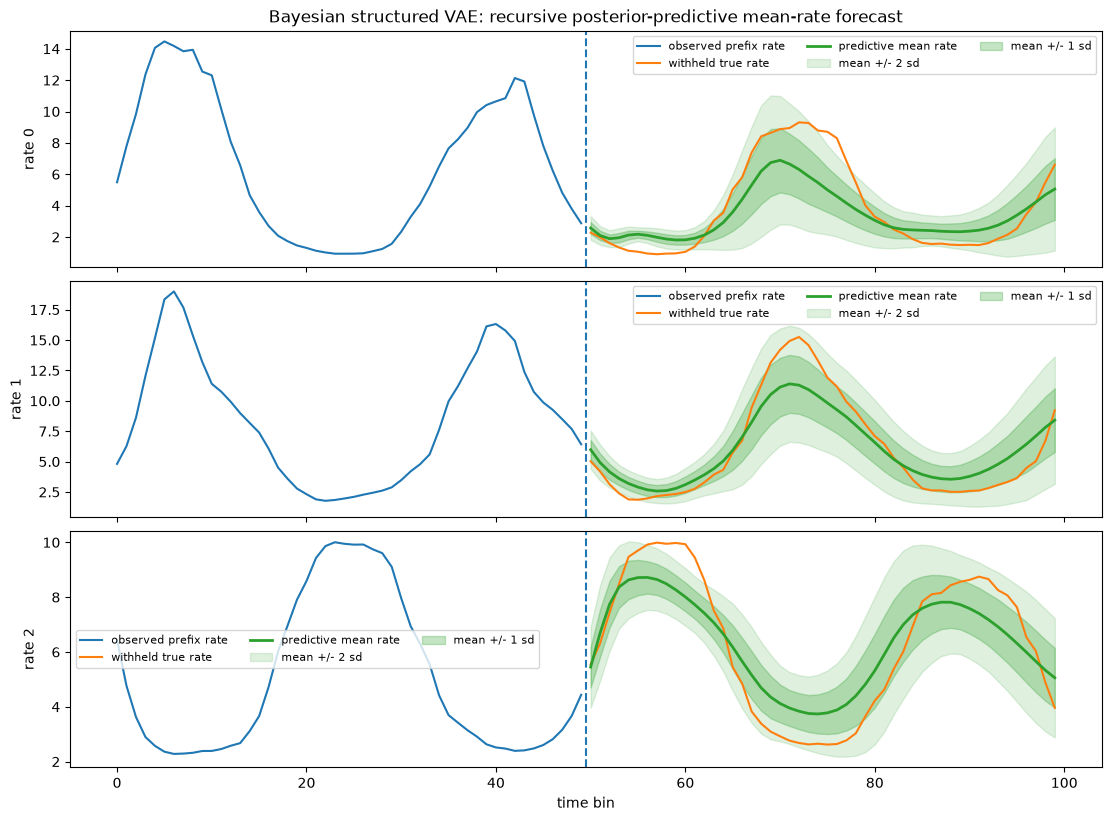

In [7]:

sf.plot_forecast_sequence(
    test_rates_full,
    point_forecast,
    T_obs,
    sequence_index=0,
    observed_dimensions=(0, 1, 2),
    title="Point structured VAE: recursive mean-rate forecast from the observed prefix",
    output_path=OUTPUT_DIR / "03_point_forecast.png",
)
plt.show()

sf.plot_forecast_sequence(
    test_rates_full,
    bayesian_forecast,
    T_obs,
    sequence_index=0,
    observed_dimensions=(0, 1, 2),
    title="Bayesian structured VAE: recursive posterior-predictive mean-rate forecast",
    output_path=OUTPUT_DIR / "04_bayesian_forecast.png",
)
plt.show()


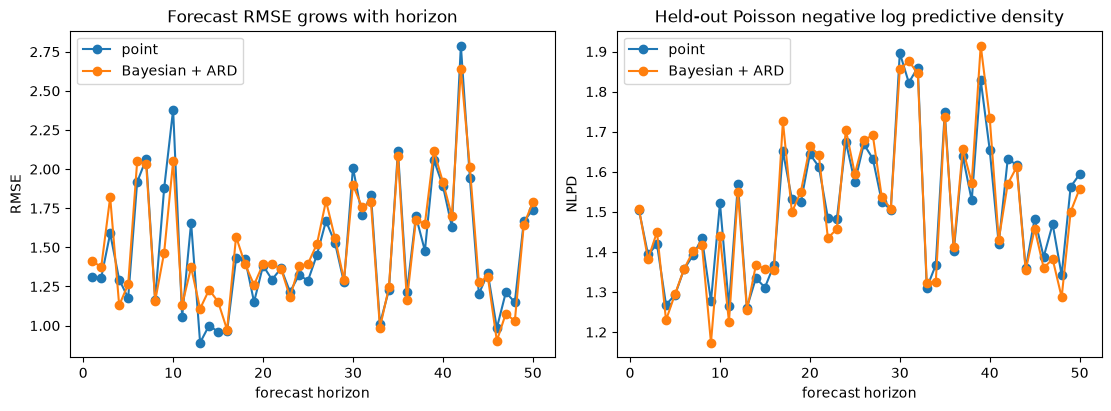

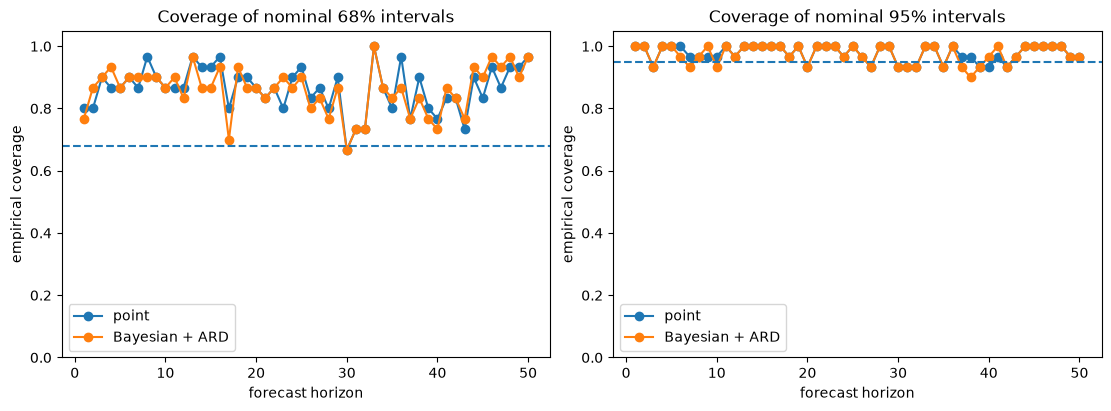

| model | RMSE | NLPD | Poisson deviance | 68% coverage | 95% coverage | aligned latent R2 | spectral radius |
|---|---|---|---|---|---|---|---|
| point | 1.486 | 1.508 | 1.347 | 0.865 | 0.977 | nan | 1.015 |
| Bayesian + ARD | 1.498 | 1.504 | 1.361 | 0.860 | 0.975 | nan | 0.984 |

In [8]:

metrics_by_model = {
    "point": point_metrics,
    "Bayesian + ARD": bayesian_metrics,
}

sf.plot_horizon_metrics(
    metrics_by_model,
    output_path=OUTPUT_DIR / "05_horizon_metrics.png",
)
plt.show()

sf.plot_interval_coverage(
    metrics_by_model,
    output_path=OUTPUT_DIR / "06_interval_coverage.png",
)
plt.show()



point_latent = sf.point_latent_diagnostics(
    point_params,
    test_prefix,
    test_latents_full[:, :T_obs],
    model_config,
)
bayesian_latent = sf.bayesian_latent_diagnostics(
    bayesian_params,
    test_prefix,
    test_latents_full[:, :T_obs],
    model_config,
)

summary_rows = []
for name, metrics, latent_score, transition in [
    ("point", point_metrics, point_latent["latent_r2"], point_params.dynamics.A),
    ("Bayesian + ARD", bayesian_metrics, bayesian_latent["latent_r2"], bayesian_params.qA.mean),
]:
    summary_rows.append(
        {
            "model": name,
            "RMSE": float(np.mean(np.asarray(metrics["rmse"]))),
            "NLPD": float(np.mean(np.asarray(metrics["nlpd"]))),
            "Poisson deviance": float(np.mean(np.asarray(metrics["poisson_deviance"]))),
            "68% coverage": float(np.mean(np.asarray(metrics["coverage68"]))),
            "95% coverage": float(np.mean(np.asarray(metrics["coverage95"]))),
            "aligned latent R2": float(latent_score),
            "spectral radius": float(sf.spectral_radius(transition)),
        }
    )

headers = list(summary_rows[0])
lines = ["| " + " | ".join(headers) + " |", "|" + "---|" * len(headers)]
for row in summary_rows:
    values = [row["model"]] + [f"{row[h]:.3f}" for h in headers[1:]]
    lines.append("| " + " | ".join(values) + " |")
display(Markdown("\n".join(lines)))



## Dynamics Recovery and ARD

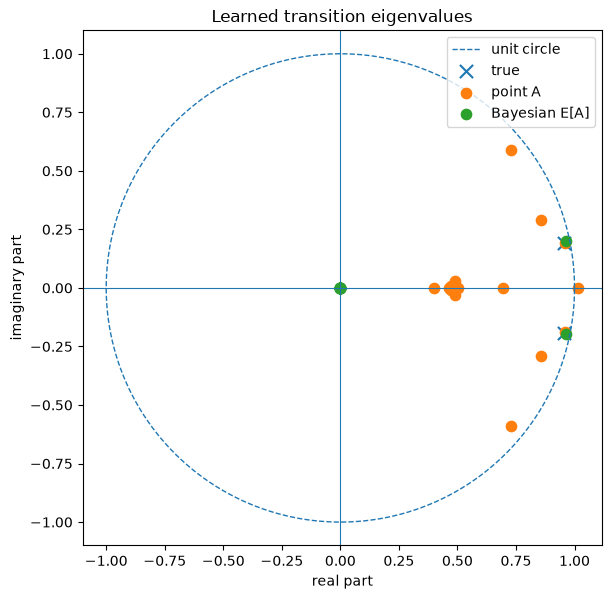

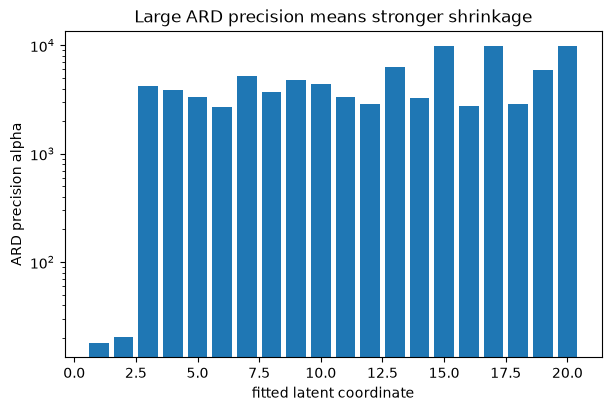

In [9]:

sf.plot_transition_eigenvalues(
    dataset.true_params.A,
    {
        "point A": point_params.dynamics.A,
        "Bayesian E[A]": bayesian_params.qA.mean,
    },
    output_path=OUTPUT_DIR / "07_transition_eigenvalues.png",
)
plt.show()

ard = sf.ard_diagnostics(bayesian_params, model_config)
sf.plot_ard(
    ard,
    output_path=OUTPUT_DIR / "08_ard.png",
)
plt.show()


## Aleatoric and epistemic forecast uncertainty

Consider the law of total variance 

$$
\operatorname{Var}(Y)
=
\mathbb E_{A,W}[\operatorname{Var}(Y\mid A,W)]
+
\operatorname{Var}_{A,W}(\mathbb E[Y\mid A,W]).
$$

The first term is considered aleatoric uncertainty. It includes the uncertainty over latents and observation noise. For forecasting, this term captures uncertainty over $z_T$ after filtering, randomness in $z_{T+1:T+h}$ from the latent dynamics, and randomness in the $y_{T+1:T+h}$ given the future latent state. The second is epistemic uncertainty, which we get with our variational posteriors over parameters. 

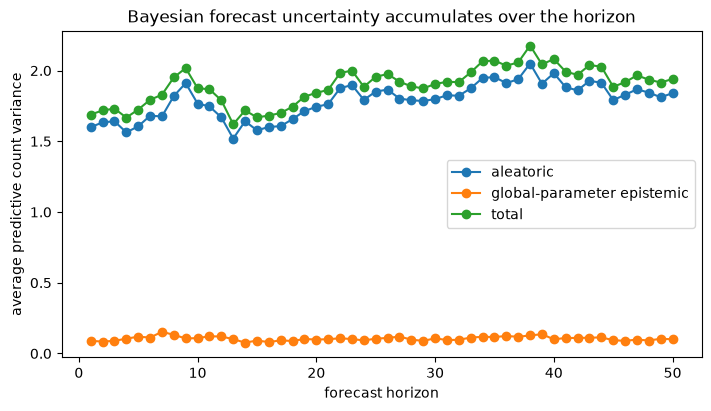

In [10]:

uncertainty = sf.bayesian_uncertainty_decomposition(
    jax.random.PRNGKey(3001),
    bayesian_params,
    test_prefix,
    H,
    num_global_samples=20,
    num_aleatoric_samples=20,
    config=model_config,
)

sf.plot_uncertainty_decomposition(
    uncertainty,
    output_path=OUTPUT_DIR / "10_uncertainty_decomposition.png",
)
plt.show()



### Summary 

### References

1. M. J. Johnson, D. Duvenaud, A. B. Wiltschko, S. R. Datta, and R. P. Adams (2016), *Composing graphical models with neural networks for structured representations and fast inference*, NeurIPS 29. [Proceedings page](https://proceedings.neurips.cc/paper/2016/hash/7d6044e95a16761171b130dcb476a43e-Abstract.html)
2. M. D. Hoffman, D. M. Blei, C. Wang, and J. Paisley (2013), *Stochastic Variational Inference*, JMLR 14. [JMLR page](https://jmlr.org/papers/v14/hoffman13a.html)
3. S. Sarkka (2013), *Bayesian Filtering and Smoothing*, Cambridge University Press. Useful background for Kalman filtering, smoothing, and information-form recursions.
4. L. Smith (2019), *A gentle introduction to information geometry*. [Blog post](https://www.robots.ox.ac.uk/~lsgs/posts/2019-09-27-info-geom.html)
5. M. E. Khan et al. (2018), *Fast and Scalable Bayesian Deep Learning by Weight-Perturbation in Adam*, ICML. [PMLR page](https://proceedings.mlr.press/v80/khan18a.html)
6. Cambridge Machine Learning Group (2021), *Natural-Gradient Variational Inference: The Maths* and *ImageNet-scale*. [Part 1](https://mlg.eng.cam.ac.uk/blog/2021/04/13/ngvi-bnns-part-1.html), [Part 2](https://mlg.eng.cam.ac.uk/blog/2021/11/24/ngvi-bnns-part-2.html)
